In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

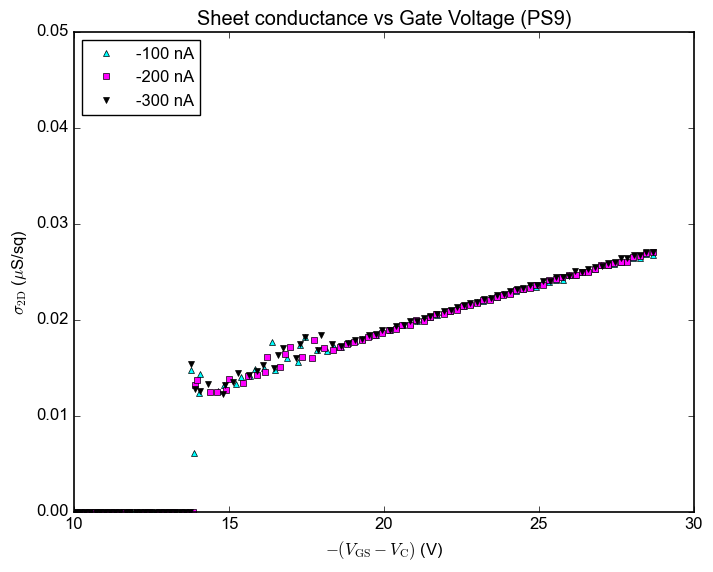

In [36]:
data1 = np.loadtxt("./Data-20260805/20260805003.dat")
data2 = np.loadtxt("./Data-20260805/20260805004.dat")
data3 = np.loadtxt("./Data-20260805/20260805005.dat")

datasets_IDS_VDS = [
    ("-100 nA", data1, 'cyan', '^'),
    ("-200 nA", data2, 'magenta', 's'),
    ("-300 nA", data3, 'black', 'v'),
]
for label, data, color, marker in datasets_IDS_VDS:
    V_GS = data[:, 0]
    I_DS = data[:, 2]
    V_DS = data[:, 3]
    V_C = 0.5*(data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]
    plt.plot(-(V_GS - V_C), sigma*1e6, label=label, color=color, marker=marker, linestyle='None', markersize=5, markevery=1)





plt.xlabel(r"$-(V_\text{GS} - V_\text{C})$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ ($\mu$S/sq)")
plt.xlim(10, 30)
plt.ylim(0, 0.05)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=12)
plt.title("Sheet conductance vs Gate Voltage (PS9)")
plt.show()

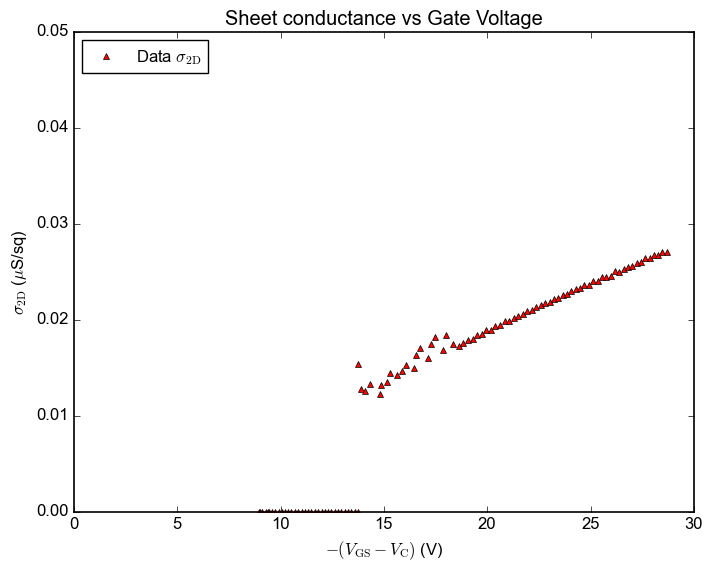

In [37]:
data = np.loadtxt("./Data-20260805/20260805005.dat")

V_GS = data[:, 0]
I_DS = data[:, 2]
V_DS = data[:, 3]
V_C = 0.5*(data[:, 4] + data[:, 5])
V_12 = data[:, 6]
sigma = data[:, 7]
plt.plot(-(V_GS - V_C), sigma*1e6, '^', label=r'Data $\sigma_\text{2D}$', color='red', markersize=5, markevery=1)




plt.xlabel(r"$-(V_\text{GS} - V_\text{C})$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ ($\mu$S/sq)")
plt.xlim(0, 30)
plt.ylim(0.0, 0.05)
plt.legend(frameon=True, loc='upper left', numpoints=1,fontsize=12)
plt.title("Sheet conductance vs Gate Voltage")
plt.show()

a = 9.64e-10 ± 7.39e-12
b = -3.01e-10 ± 1.79e-10
R^2 = 0.998
V_T = (-0.312 ± 0.185) V
mu_int = (0.138 ± 0.00105) cm^2/Vs


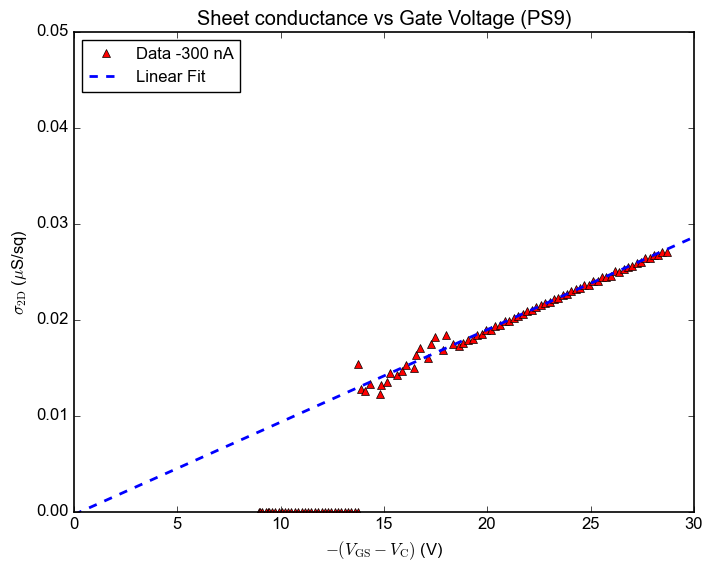

In [38]:
C = 2.242e-9  # F
A = 32e-6  # m^2
Ci = C / A  # F/m^2
V_del_full = -(V_GS - V_C)
sigma_full = sigma.copy()

mask = (V_del_full > 20) & (V_del_full < 28)
V_del = V_del_full[mask]
sigma = sigma_full[mask]

def func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(func, V_del, sigma)
sigma_fit = func(V_del, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((sigma - sigma_fit) ** 2)
ss_tot = np.sum((sigma - np.mean(sigma)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr
V_T_fit = b / a
V_T_err = abs(V_T_fit) * np.sqrt((b_err / b) ** 2 + (a_err / a) ** 2)
mu_fit = a / Ci * 1e4
mu_err = abs(mu_fit * a_err / a)

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"R^2 = {r2:.3f}")

print(f"V_T = ({V_T_fit:.3g} ± {V_T_err:.3g}) V")
print(f"mu_int = ({mu_fit:.3g} ± {mu_err:.3g}) cm^2/Vs")

x = np.linspace(0, 60, 100)
plt.plot(V_del_full, sigma_full*1e6, '^', label=r'Data -300 nA', color='red', markersize=6, markevery=1)
plt.plot(x, func(x, *popt) * 1e6, lw=2, label='Linear Fit', color='blue', linestyle='--')
plt.xlabel(r"$-(V_\text{GS} - V_\text{C})$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ ($\mu$S/sq)")
plt.xlim(0, 30)
plt.ylim(0, 0.05)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=12)
plt.title("Sheet conductance vs Gate Voltage (PS9)")
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()